# Hierarchical refinement with low-rank Sinkhorn

For large-scale matching and assignment problems, dense Sinkhorn quickly becomes
impractical because of quadratic space and time complexity. Low-rank OT reduces
the memory footprint, but a single low-rank coupling can be too coarse to define
a high-quality pointwise matching. [Hierarchical Refinement (HiRef)](https://openreview.net/forum?id=EBNgREMoVD) 
addresses this by recursively solving low-rank OT subproblems, with the goal of producing a
bijective Monge map in log-linear time and linear space.

At each refinement step, a low-rank solve forms matched co-clusters,

$$
\{(X_z, Y_z)\}_{z=1}^r,
$$

where each pair contains source and target points assigned to the same latent
component. We call a pair that still needs refinement an active block. Each
refinement level replaces every active block by several smaller matched blocks.
At the final scale, exact assignment is applied only inside small square leaves.

OTT-JAX provides {class}`~ott.solvers.linear.sinkhorn_lr.LRSinkhorn`, a solver
that returns low-rank factors `q`, `r`, and `g` for a regularized linear OT
problem. This notebook uses those factors to build a batched, HiRef-inspired
coarse-to-fine matching procedure with OTT primitives.

For this tutorial, we aim to match two 65,536-point pinwheel clouds. The source
has eight curved arms; the target is a twisted, sheared, translated, and
permuted version of the same points.

## Imports

In [1]:
import functools
import operator
import time

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
import numpy as np

from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn_lr
from ott.tools import unreg

## A pinwheel matching problem

The source cloud is ordered by arm and radius. The target applies a smooth
nonlinear twist and then permutes the rows.

In [2]:
def make_pinwheel_clouds(n=65_536, arms=8, noise=0.015):
    """Create a deterministic pinwheel source and a twisted target."""
    key_noise, key_perm = jax.random.split(jax.random.key(7))

    # Parameterize each arm by a discrete arm id and a radial coordinate. 
    points_per_arm = n // arms
    arm = jnp.repeat(jnp.arange(arms), points_per_arm)
    t = jnp.tile(jnp.linspace(0.08, 1.0, points_per_arm), arms)

    # Build the source as eight curved arms with small deterministic noise.
    base_angle = 2.0 * jnp.pi * arm / arms
    theta = base_angle + 1.35 * t + 0.12 * jnp.sin(4.0 * jnp.pi * t)
    radius = 0.25 + 1.15 * t + 0.08 * jnp.sin(6.0 * jnp.pi * t)
    x = jnp.stack([radius * jnp.cos(theta), radius * jnp.sin(theta)], axis=1)
    x = x + noise * jax.random.normal(key_noise, x.shape)

    # Create the target.
    r = jnp.linalg.norm(x, axis=1)
    angle = jnp.arctan2(x[:, 1], x[:, 0]) + 0.55 + 0.35 * r
    scale = 0.88 + 0.18 * jnp.sin(arms * angle)
    y = jnp.stack(
        [scale * r * jnp.cos(angle), 1.08 * scale * r * jnp.sin(angle)],
        axis=1,
    )
    shear = jnp.array([[1.0, 0.14], [-0.06, 1.0]])
    y = y @ shear.T + jnp.array([0.28, -0.16])
    y = y + noise * jax.random.normal(jax.random.fold_in(key_noise, 1), y.shape)

    perm = jax.random.permutation(key_perm, n)
    return x, y[perm], arm, arm[perm]


n = 65_536
x, y, _, _ = make_pinwheel_clouds(n=n)

In [5]:
def evenly_spaced_ids(n_items, max_items):
    # subsampling for plots.
    if n_items <= max_items:
        return np.arange(n_items, dtype=np.int32)
    return np.linspace(0, n_items - 1, max_items, dtype=np.int32)


def plot_clouds(x, y, *, title, max_points=12_000):
    """Plot a subset of the source and target clouds."""
    x_np, y_np = np.asarray(x), np.asarray(y)
    ids = evenly_spaced_ids(x_np.shape[0], max_points)

    fig, ax = plt.subplots(figsize=(5.6, 5.6))
    ax.scatter(
        x_np[ids, 0],
        x_np[ids, 1],
        s=5,
        color="#1f77b4",
        marker="o",
        label=f"source x ({len(ids)} shown)",
        alpha=0.62,
        linewidths=0,
        zorder=2,
    )
    ax.scatter(
        y_np[ids, 0],
        y_np[ids, 1],
        s=7,
        color="#d95f02",
        marker="x",
        label=f"target y ({len(ids)} shown)",
        alpha=0.70,
        linewidths=0.45,
        zorder=3,
    )
    ax.set_title(title)
    ax.set_xlabel("coordinate 1")
    ax.set_ylabel("coordinate 2")
    ax.set_aspect("equal")
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.legend(title="cloud", loc="upper right")
    fig.tight_layout()
    plt.show()



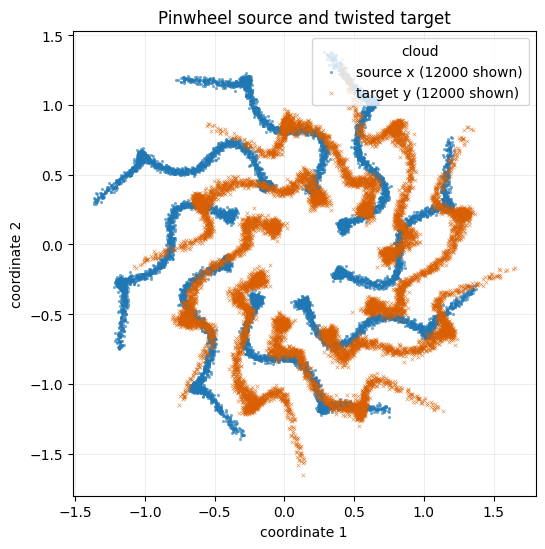

In [6]:
plot_clouds(x, y, title="Pinwheel source and twisted target")

## Rank schedule

A refinement schedule $(r_1,\ldots,r_k)$ specifies how many children each
active block is split into at each low-rank level. Its cumulative refinement
factor after level $t$ is

$$
\rho_t := \prod_{s=1}^t r_s.
$$

Thus, after level $t$, $\rho_t$ is the number of active blocks, i.e., the number of paired 
subsets $(X_i,Y_j)$ that have not yet reached terminal leaf size. If the terminal
leaf size is $\ell$, then $\rho_k \ell = n$.

In the reference implementation, the
[HiRef rank-annealing helper](https://github.com/raphael-group/HiRef/blob/main/src/rank_annealing.py)
first factors out a terminal base-case size, then factors the remaining quotient
into intermediate ranks. It chooses those ranks by minimizing the number of
low-rank subproblems in the balanced tree,

$$
1 + \rho_1 + \cdots + \rho_{k-1},
$$

subject to a maximum intermediate rank.

The next code block closely follows that helper: it factors out the terminal
leaf size, solves the same dynamic program over intermediate ranks, sorts the
intermediate factors, appends the terminal factor, and removes dummy factors
equal to one. The bound is strict: $\ell$ is the largest factor of
$n$ with $\ell < \texttt{max\_leaf\_size}$.

In [7]:
def factors(number):
    # Return all positive factors. 
    # Naive but the scheduler only uses this on small
    # quotients.
    out = []
    for candidate in range(1, int(number**0.5) + 1):
        if number % candidate == 0:
            out.extend([candidate, number // candidate])
    return sorted(set(out))


def max_factor_lX(number, max_x):
    valid = [factor for factor in factors(number) if factor < max_x]
    if not valid:
        raise ValueError("number has no positive factor strictly below max_x.")
    return max(valid)


def min_sum_partial_products_with_factors(number, depth, max_rank):
    # Dynamic program from the HiRef rank-annealing helper. `dp[d][t]` stores
    # the best objective value for factoring `d` into exactly `t` factors.
    inf = float("inf")
    dp = [[inf] * (depth + 1) for _ in range(number + 1)]
    choice = [[-1] * (depth + 1) for _ in range(number + 1)]

    # With one remaining level, the only possible factor is the number itself,
    # provided it does not exceed the maximum allowed rank.
    for divisor in range(1, number + 1):
        if divisor <= max_rank:
            dp[divisor][1] = divisor
            choice[divisor][1] = divisor

    # If the first factor is `rank`, the later factors split `divisor / rank`.
    # Multiplying their objective by `rank` accounts for solving that many
    # child subproblems at the next levels.
    for level in range(2, depth + 1):
        for divisor in range(1, number + 1):
            for rank in range(1, min(max_rank, divisor) + 1):
                if divisor % rank == 0:
                    candidate = rank + rank * dp[divisor // rank][level - 1]
                    if candidate < dp[divisor][level]:
                        dp[divisor][level] = candidate
                        choice[divisor][level] = rank

    if dp[number][depth] == inf:
        return None, []

    # Reconstruct the selected factors by following the choices backward.
    schedule = []
    divisor = number
    level = depth
    while level > 0:
        rank = choice[divisor][level]
        schedule.append(rank)
        divisor //= rank
        level -= 1
    return dp[number][depth], schedule


def optimal_rank_schedule(
    number, hierarchy_depth=6, max_leaf_size=256, max_rank=16
):
    # The terminal base-case factor is removed first, exactly as in HiRef's
    # helper. In this tutorial it becomes the exact-assignment leaf size.
    leaf_size = max_factor_lX(number, max_leaf_size)
    reduced = number // leaf_size

    # Factor the remaining problem into intermediate low-rank levels.
    _, schedule = min_sum_partial_products_with_factors(
        reduced, hierarchy_depth, max_rank
    )

    # The reference helper sorts the intermediate factors, appends the terminal
    # base-case factor, and removes dummy factors equal to one.
    schedule.sort()
    schedule.append(leaf_size)
    schedule = [rank for rank in schedule if rank != 1]
    assert functools.reduce(operator.mul, schedule) == number
    return schedule


def partial_products(schedule):
    # Effective ranks: [r_1, r_1 r_2, ...].
    products = []
    product = 1
    for rank in schedule:
        product *= int(rank)
        products.append(product)
    return products


def low_rank_solve_count(schedule):
    # At a level with `active_block_count` active blocks, we solve one low-rank
    # OT problem per active block.
    solves = 0
    active_block_count = 1
    for rank in schedule:
        solves += active_block_count
        active_block_count *= int(rank)
    return solves


hierarchy_depth = 6
max_leaf_size = 256
max_rank = 16
rank_schedule = optimal_rank_schedule(n, hierarchy_depth, max_leaf_size, max_rank)
lr_rank_schedule = rank_schedule[:-1]
leaf_size = rank_schedule[-1]
rank_partials = partial_products(rank_schedule)

assert rank_schedule == [2, 16, 16, 128]
assert lr_rank_schedule == [2, 16, 16]
assert leaf_size == 128
assert int(np.prod(rank_schedule)) == n

schedule_summary = {
    "rank_schedule": rank_schedule,
    "lr_rank_schedule": lr_rank_schedule,
    "leaf_size": leaf_size,
    "effective_ranks": rank_partials,
    "final_leaves": rank_partials[-2],
    "low_rank_solves": low_rank_solve_count(lr_rank_schedule),
}
schedule_summary

{'rank_schedule': [2, 16, 16, 128],
 'lr_rank_schedule': [2, 16, 16],
 'leaf_size': 128,
 'effective_ranks': [2, 32, 512, 65536],
 'final_leaves': 512,
 'low_rank_solves': 35}

We can also check how the calculated rank schedule and the number of subproblems change as the `max_leaf_size` varies:

In [8]:
schedule_tradeoff = []
for candidate_max_leaf_size in [128, 256, 512, 1024]:
    candidate_schedule = optimal_rank_schedule(
        n,
        hierarchy_depth=hierarchy_depth,
        max_leaf_size=candidate_max_leaf_size,
        max_rank=max_rank,
    )
    candidate_prefix = candidate_schedule[:-1]
    candidate_partials = partial_products(candidate_schedule)
    schedule_tradeoff.append(
        {
            "max_leaf_size": candidate_max_leaf_size,
            "rank_schedule": candidate_schedule,
            "leaf_size": candidate_schedule[-1],
            "leaves_before_terminal": candidate_partials[-2],
            "lr_solves": low_rank_solve_count(candidate_prefix),
        }
    )
schedule_tradeoff

[{'max_leaf_size': 128,
  'rank_schedule': [4, 16, 16, 64],
  'leaf_size': 64,
  'leaves_before_terminal': 1024,
  'lr_solves': 69},
 {'max_leaf_size': 256,
  'rank_schedule': [2, 16, 16, 128],
  'leaf_size': 128,
  'leaves_before_terminal': 512,
  'lr_solves': 35},
 {'max_leaf_size': 512,
  'rank_schedule': [16, 16, 256],
  'leaf_size': 256,
  'leaves_before_terminal': 256,
  'lr_solves': 17},
 {'max_leaf_size': 1024,
  'rank_schedule': [8, 16, 512],
  'leaf_size': 512,
  'leaves_before_terminal': 128,
  'lr_solves': 9}]

Increasing `max_leaf_size` reduces the number of low-rank subproblems, but leaves more work for the terminal exact
assignments.


We use the schedule `[2, 16, 16, 128]`. We use the first
three entries, `[2, 16, 16]`, as low-rank refinement levels. They create

$$
\rho_3 = 2 \cdot 16 \cdot 16 = 512
$$

terminal leaves. Since $n = 65{,}536$, each leaf contains

$$
\ell = n / \rho_3 = 128
$$

source points and 128 target points. The last schedule entry is therefore not
another low-rank refinement level in this notebook; it is the leaf size at which
we switch to exact local assignment.


## One low-rank block solve

The paper's HiRef subproblem uses a fixed uniform inner marginal $g:=\mathbf{1}_r/r$. OTT's
`LRSinkhorn` does not expose a `fixed_g` flag, but its balanced Dykstra
projection accepts a lower bound on entries of `g`. Setting that lower bound
to $1/r$ forces $g_z = 1/r$ in exact arithmetic, because $\sum_{z=1}^r g_z =1$ as it is a probability
vector. The tolerance below controls the numerical accuracy of that
projection.

In [9]:
epsilon = 0.05
lr_epsilon = 0.0
lr_max_iterations = 50
lr_threshold = 1e-2
dykstra_tolerance = 1e-3
g_uniform_tolerance = 5e-3


def lr_kwargs_dys(rank):
    # The Dykstra projection enforces g_z >= min_entry_value. Setting this to
    # 1 / rank makes the only feasible probability vector the uniform vector,
    # up to numerical tolerance.
    return {
        "min_entry_value": 1.0 / rank,
        "tolerance": dykstra_tolerance,
    }


def uniform_g_error(g, rank):
    # Report the largest coordinate-wise deviation from the intended uniform
    # inner marginal.
    return jnp.max(jnp.abs(g - 1.0 / rank))


def solve_lr_block(x_block, y_block, rank):
    geom = pointcloud.PointCloud(x_block, y_block, epsilon=epsilon)
    prob = linear_problem.LinearProblem(geom)

    solver = sinkhorn_lr.LRSinkhorn(
        rank=rank,
        epsilon=lr_epsilon,
        max_iterations=lr_max_iterations,
        threshold=lr_threshold,
        kwargs_dys=lr_kwargs_dys(rank),
    )

    rng = jax.random.PRNGKey(int(x_block.shape[0]) * 31 + int(rank))
    return solver(prob, rng=rng)


first_lr_out = solve_lr_block(x, y, rank_schedule[0])
print(
    {
        "q": first_lr_out.q.shape,
        "r": first_lr_out.r.shape,
        "g": first_lr_out.g.shape,
        "converged": bool(first_lr_out.converged),
        "regularized_cost": float(first_lr_out.reg_ot_cost),
        "max_g_uniform_error": float(
            uniform_g_error(first_lr_out.g, rank_schedule[0])
        ),
    }
)

assert float(uniform_g_error(first_lr_out.g, rank_schedule[0])) < g_uniform_tolerance

{'q': (65536, 2), 'r': (65536, 2), 'g': (2,), 'converged': True, 'regularized_cost': 1.0780240297317505, 'max_g_uniform_error': 6.9141387939453125e-06}


The factors define the low-rank plan

$$
P_r = Q \operatorname{diag}(1/g) R^\top.
$$

We do not materialize $P_r$. Refinement only uses the rows of $Q$ and $R$ as
soft scores for shared components.

## From soft scores to blocks

The rows of $Q$ and $R$ are soft component scores, not a partition. A literal
discretization would use

$$
z_x(i) = \operatorname*{arg max}_z Q_{iz},
\qquad
z_y(j) = \operatorname*{arg max}_z R_{jz}.
$$

With soft factors, this can give source and target children with different
sizes even when the inner marginal is uniform. We use the capacity-preserving idea from a [HiRef
implementation](https://github.com/peterhalmos/HiRef): for each component, take the top `block_size / rank`
remaining rows by that component score. This creates disjoint equal-size
children.

In [10]:
def argmax_size_summary(q, r):
    # This diagnostic shows why raw argmax labels are not enough for a square
    # terminal assignment: source and target component counts need not agree.
    x_labels = np.asarray(jnp.argmax(q, axis=1))
    y_labels = np.asarray(jnp.argmax(r, axis=1))
    return {
        "source_argmax_sizes": np.bincount(x_labels, minlength=q.shape[1]).tolist(),
        "target_argmax_sizes": np.bincount(y_labels, minlength=r.shape[1]).tolist(),
    }


argmax_size_summary(first_lr_out.q, first_lr_out.r)

{'source_argmax_sizes': [32760, 32776], 'target_argmax_sizes': [32799, 32737]}

In [11]:
def capacity_partition(scores):
    """Split rows into equal-capacity groups using component scores."""
    block_size, rank = scores.shape
    capacity = block_size // rank

    # `selected[i]` records whether row `i` has already been assigned to an
    # earlier component. This makes the groups disjoint.
    selected = jnp.zeros((block_size,), dtype=bool)

    def step(selected, component):
        # Ignore rows already assigned to a previous component.
        masked_scores = jnp.where(selected, -jnp.inf, scores[:, component])

        # Choose exactly `capacity` rows with the largest score for this
        # component. This mirrors the capacity-aware split in the HiRef code.
        _, local_idx = jax.lax.top_k(masked_scores, capacity)

        # Mark the chosen rows before moving to the next component.
        selected = selected.at[local_idx].set(True)
        return selected, jnp.sort(local_idx)

    # Scan over components so the selection for later components sees the rows
    # taken by earlier components.
    _, parts = jax.lax.scan(step, selected, jnp.arange(rank))
    return parts


def make_batched_capacity_partition():
    # All active blocks at a level have the same shape, so one compiled vmapped
    # partition function can split every block at that level.
    return jax.jit(jax.vmap(capacity_partition))


first_x_parts = np.asarray(capacity_partition(first_lr_out.q))
first_y_parts = np.asarray(capacity_partition(first_lr_out.r))
[len(part) for part in first_x_parts], [len(part) for part in first_y_parts]

([32768, 32768], [32768, 32768])

In [12]:
def plot_partitions(x, y, x_parts, y_parts, *, title, max_per_child=5000):
    x_np, y_np = np.asarray(x), np.asarray(y)
    colors = plt.cm.tab10(np.linspace(0.0, 1.0, len(x_parts)))
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2), sharex=True, sharey=True)

    for part, idx in enumerate(x_parts):
        ids = idx[evenly_spaced_ids(len(idx), max_per_child)]
        axes[0].scatter(
            x_np[ids, 0],
            x_np[ids, 1],
            s=5,
            color=colors[part],
            marker="o",
            label=f"child {part}",
            alpha=0.68,
            linewidths=0,
        )
    for part, idx in enumerate(y_parts):
        ids = idx[evenly_spaced_ids(len(idx), max_per_child)]
        axes[1].scatter(
            y_np[ids, 0],
            y_np[ids, 1],
            s=7,
            color=colors[part],
            marker="x",
            label=f"child {part}",
            alpha=0.72,
            linewidths=0.45,
        )

    axes[0].set_title("source children from q")
    axes[1].set_title("target children from r")
    for ax in axes:
        ax.set_xlabel("coordinate 1")
        ax.set_aspect("equal")
        ax.grid(alpha=0.25, linewidth=0.6)
        ax.legend(title="child", loc="upper right")
    axes[0].set_ylabel("coordinate 2")
    fig.suptitle(title)
    fig.tight_layout()
    return fig

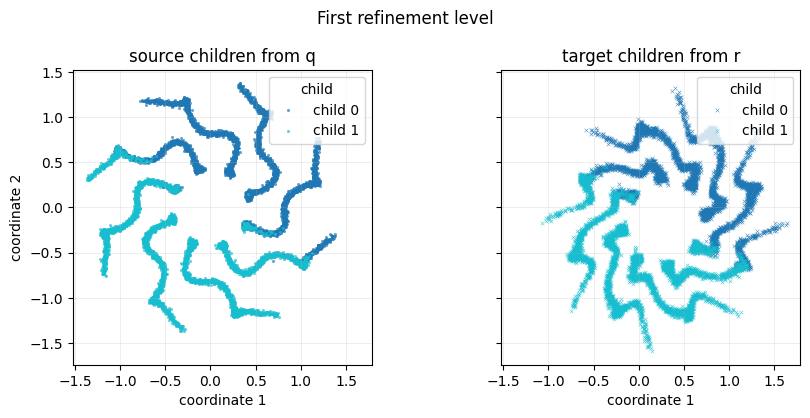

In [13]:
partition_fig = plot_partitions(
    x,
    y,
    first_x_parts,
    first_y_parts,
    title="First refinement level",
)
plt.show()

## Batched hierarchical refinement

The algorithm keeps a collection of active paired blocks. Each block contains
source indices and target indices that should be refined together. For
performance, we store that collection as arrays:

- `x_blocks`, `y_blocks`: `(num_blocks, block_size, 2)`,
- `idx_x_blocks`, `idx_y_blocks`: `(num_blocks, block_size)`.

At each level, all blocks have the same shape. We therefore compile one
batched `LRSinkhorn` solve with `jax.jit` and `jax.vmap`, split every block,
and continue to the next level.

In [14]:
def make_solve_lr_level(rank):
    def solve_one(x_block, y_block, rng):
        # This is the same single-block OTT solve as above, written inside a
        # function so JAX can vectorize it over many active blocks.
        geom = pointcloud.PointCloud(x_block, y_block, epsilon=epsilon)
        prob = linear_problem.LinearProblem(geom)
        solver = sinkhorn_lr.LRSinkhorn(
            rank=rank,
            epsilon=lr_epsilon,
            max_iterations=lr_max_iterations,
            threshold=lr_threshold,
            kwargs_dys=lr_kwargs_dys(rank),
        )
        out = solver(prob, rng=rng)
        return out.q, out.r, out.g, out.reg_ot_cost, out.converged

    # Compile one vectorized solve for all blocks at this level.
    return jax.jit(jax.vmap(solve_one, in_axes=(0, 0, 0)))


def refine_one_level(x_blocks, y_blocks, idx_x_blocks, idx_y_blocks, rank, rng):
    # Solve one low-rank OT problem per active block, all in a single vmapped
    # call. The result has shape `(num_blocks, block_size, rank)` for `q` and
    # `r`.
    solve_level = make_solve_lr_level(rank)
    keys = jax.random.split(rng, x_blocks.shape[0])
    q, r, g, costs, converged = solve_level(x_blocks, y_blocks, keys)

    # Synchronize before timing and before using `q` in the host-side summary.
    q.block_until_ready()

    # Convert soft scores into equal-size child indices for every active block.
    partition_level = make_batched_capacity_partition()
    x_parts = partition_level(q)
    y_parts = partition_level(r)

    # Each active block is split into `rank` children, each of size
    # `block_size / rank`.
    num_blocks, block_size, dimension = x_blocks.shape
    child_size = block_size // rank

    # Gather source child point coordinates. The temporary singleton axis after
    # `x_blocks[:, None, :, :]` aligns the block array with `x_parts`, whose
    # shape is `(num_blocks, rank, child_size)`.
    x_blocks_next = jnp.take_along_axis(
        x_blocks[:, None, :, :], x_parts[..., None], axis=2
    ).reshape(num_blocks * rank, child_size, dimension)

    # Gather target child point coordinates using the target-side partition.
    y_blocks_next = jnp.take_along_axis(
        y_blocks[:, None, :, :], y_parts[..., None], axis=2
    ).reshape(num_blocks * rank, child_size, dimension)

    # Carry global source indices through the same source-side gather. These
    # indices are needed later to assemble a global sparse matching.
    idx_x_next = jnp.take_along_axis(
        idx_x_blocks[:, None, :], x_parts, axis=2
    ).reshape(num_blocks * rank, child_size)

    # Carry global target indices through the target-side gather.
    idx_y_next = jnp.take_along_axis(
        idx_y_blocks[:, None, :], y_parts, axis=2
    ).reshape(num_blocks * rank, child_size)

    # Force the gather to finish before recording elapsed time.
    x_blocks_next.block_until_ready()

    return (
        x_blocks_next,
        y_blocks_next,
        idx_x_next,
        idx_y_next,
        {
            "rank": rank,
            "input_blocks": num_blocks,
            "input_block_size": block_size,
            "output_blocks": num_blocks * rank,
            "output_block_size": child_size,
            "converged_solves": int(jnp.sum(converged)),
            "regularized_cost_mean": float(jnp.mean(costs)),
            "max_g_uniform_error": float(jnp.max(jnp.abs(g - 1.0 / rank))),
        },
    )


def hierarchical_refinement(x, y, schedule):
    # Start from one active block containing all source points and all target
    # points.
    x_blocks = x[None, :, :]
    y_blocks = y[None, :, :]
    idx_x_blocks = jnp.arange(x.shape[0], dtype=jnp.int32)[None, :]
    idx_y_blocks = jnp.arange(y.shape[0], dtype=jnp.int32)[None, :]

    # One base key is folded by level so every level is deterministic but uses
    # distinct random initialization keys.
    key = jax.random.key(101)
    level_summaries = []
    hierarchy_start = time.perf_counter()

    for level, rank in enumerate(schedule):
        # Apply one rank in the schedule: every active block is replaced by
        # `rank` smaller active blocks.
        level_start = time.perf_counter()
        (
            x_blocks,
            y_blocks,
            idx_x_blocks,
            idx_y_blocks,
            summary,
        ) = refine_one_level(
            x_blocks,
            y_blocks,
            idx_x_blocks,
            idx_y_blocks,
            rank,
            jax.random.fold_in(key, level),
        )
        summary["elapsed_seconds"] = time.perf_counter() - level_start
        level_summaries.append(summary)

    # Return terminal blocks plus per-level diagnostics. The terminal blocks are
    # not yet one-to-one assignments; they are small square assignment problems.
    return {
        "x_blocks": x_blocks,
        "y_blocks": y_blocks,
        "idx_x_blocks": idx_x_blocks,
        "idx_y_blocks": idx_y_blocks,
        "level_summaries": level_summaries,
        "hierarchy_seconds": time.perf_counter() - hierarchy_start,
    }


refined = hierarchical_refinement(x, y, lr_rank_schedule)
print(refined["level_summaries"])
print({"hierarchy_seconds": refined["hierarchy_seconds"]})

assert refined["x_blocks"].shape == (512, leaf_size, 2)
assert refined["y_blocks"].shape == (512, leaf_size, 2)
assert refined["idx_x_blocks"].shape == (512, leaf_size)
assert refined["idx_y_blocks"].shape == (512, leaf_size)
assert refined["hierarchy_seconds"] > 0.0
assert all(
    summary["max_g_uniform_error"] < g_uniform_tolerance
    for summary in refined["level_summaries"]
)

[{'rank': 2, 'input_blocks': 1, 'input_block_size': 65536, 'output_blocks': 2, 'output_block_size': 32768, 'converged_solves': 1, 'regularized_cost_mean': 1.0558161735534668, 'max_g_uniform_error': 2.1576881408691406e-05, 'elapsed_seconds': 0.8979530420037918}, {'rank': 16, 'input_blocks': 2, 'input_block_size': 32768, 'output_blocks': 32, 'output_block_size': 2048, 'converged_solves': 2, 'regularized_cost_mean': 0.5558744668960571, 'max_g_uniform_error': 0.0014111101627349854, 'elapsed_seconds': 3.3891725839930587}, {'rank': 16, 'input_blocks': 32, 'input_block_size': 2048, 'output_blocks': 512, 'output_block_size': 128, 'converged_solves': 32, 'regularized_cost_mean': 0.2068309485912323, 'max_g_uniform_error': 0.0014927014708518982, 'elapsed_seconds': 12.990485374990385}]
{'hierarchy_seconds': 17.2776182089583}


## Exact terminal assignments

The terminal leaves are $128 \times 128$, so exact assignment is still small
locally. We use {func}`ott.tools.unreg.hungarian <ott.tools.unreg.hungarian>`
in a batched `vmap` over all leaves.

In [15]:
def make_batched_hungarian():
    def solve_one(x_block, y_block):
        # Each terminal leaf is a square point-cloud matching problem.
        cost, hard = unreg.hungarian(pointcloud.PointCloud(x_block, y_block))
        return cost, hard.paired_indices

    # Compile one batched Hungarian call over all terminal leaves.
    return jax.jit(jax.vmap(solve_one, in_axes=(0, 0)))


def assignment_from_blocks(x, y, refined):
    assignment_start = time.perf_counter()

    # `local_pairs` stores row/column indices inside each terminal leaf, not
    # global point ids.
    solve_hungarian = make_batched_hungarian()
    costs, local_pairs = solve_hungarian(refined["x_blocks"], refined["y_blocks"])
    costs.block_until_ready()

    # Split the local source and target indices returned by Hungarian.
    local_rows = local_pairs[:, 0, :]
    local_cols = local_pairs[:, 1, :]

    # Convert local leaf indices back to global source/target point ids.
    row_ind = jnp.take_along_axis(refined["idx_x_blocks"], local_rows, axis=1)
    col_ind = jnp.take_along_axis(refined["idx_y_blocks"], local_cols, axis=1)

    # Flatten all leaf matchings into one sparse global matching.
    row_ind = row_ind.reshape(-1)
    col_ind = col_ind.reshape(-1)

    # Compute the mean squared Euclidean cost of the assembled matching.
    diff = x[row_ind] - y[col_ind]
    assignment_cost = jnp.mean(jnp.sum(diff * diff, axis=1))
    assignment_cost.block_until_ready()

    return {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "leaf_costs": costs,
        "assignment_cost": assignment_cost,
        "assignment_seconds": time.perf_counter() - assignment_start,
    }


assignment = assignment_from_blocks(x, y, refined)
row_ind = np.asarray(assignment["row_ind"])
col_ind = np.asarray(assignment["col_ind"])
hierarchical_cost = float(assignment["assignment_cost"])
timing_summary = {
    "hierarchy_seconds": refined["hierarchy_seconds"],
    "assignment_seconds": assignment["assignment_seconds"],
    "matched_pairs": int(row_ind.shape[0]),
    "assignment_cost": hierarchical_cost,
}
print(timing_summary)

assert row_ind.shape[0] == n
assert col_ind.shape[0] == n
assert np.array_equal(np.sort(row_ind), np.arange(n))
assert np.array_equal(np.sort(col_ind), np.arange(n))
assert np.isfinite(hierarchical_cost)
assert assignment["assignment_seconds"] > 0.0

{'hierarchy_seconds': 17.2776182089583, 'assignment_seconds': 2.5135583749506623, 'matched_pairs': 65536, 'assignment_cost': 0.13465075194835663}


## Sparse matching plot

Now we visualize the final matching. The assignment is stored as source and
target index pairs, so we plot a deterministic sample of matched pairs as line
segments.

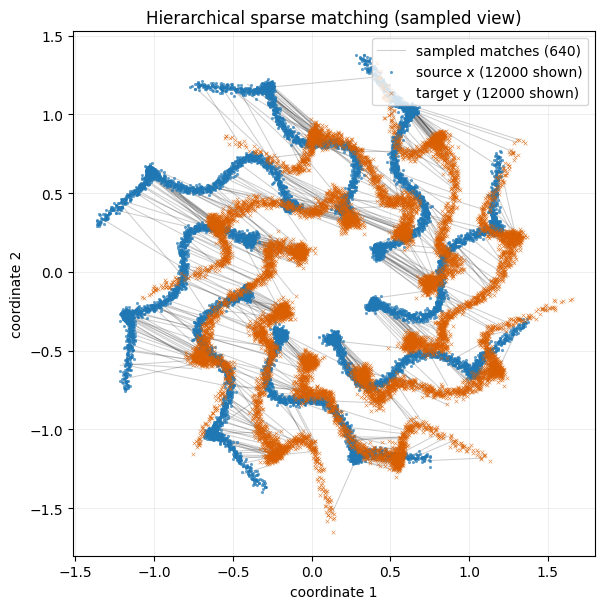

In [16]:
def plot_sparse_assignment(
    x,
    y,
    row_ind,
    col_ind,
    *,
    max_points=12_000,
    max_lines=640,
    title,
):
    x_np, y_np = np.asarray(x), np.asarray(y)
    row_ind = np.asarray(row_ind)
    col_ind = np.asarray(col_ind)

    point_ids = evenly_spaced_ids(x_np.shape[0], max_points)
    line_ids = evenly_spaced_ids(row_ind.shape[0], max_lines)

    fig, ax = plt.subplots(figsize=(6.2, 6.2))
    for line_number, idx in enumerate(line_ids):
        # Draw sampled match segments behind the point clouds.
        xi = x_np[row_ind[idx]]
        yi = y_np[col_ind[idx]]
        ax.plot(
            [xi[0], yi[0]],
            [xi[1], yi[1]],
            color="0.20",
            alpha=0.24,
            lw=0.75,
            label=f"sampled matches ({len(line_ids)})" if line_number == 0 else None,
            zorder=1,
        )

    ax.scatter(
        x_np[point_ids, 0],
        x_np[point_ids, 1],
        s=5,
        color="#1f77b4",
        marker="o",
        label=f"source x ({len(point_ids)} shown)",
        alpha=0.70,
        linewidths=0,
        zorder=2,
    )
    ax.scatter(
        y_np[point_ids, 0],
        y_np[point_ids, 1],
        s=7,
        color="#d95f02",
        marker="x",
        label=f"target y ({len(point_ids)} shown)",
        alpha=0.72,
        linewidths=0.45,
        zorder=3,
    )
    ax.set_title(title)
    ax.set_xlabel("coordinate 1")
    ax.set_ylabel("coordinate 2")
    ax.set_aspect("equal")
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.legend(loc="upper right")
    fig.tight_layout()
    return fig


assignment_fig = plot_sparse_assignment(
    x,
    y,
    row_ind,
    col_ind,
    title="Hierarchical sparse matching (sampled view)",
)
plt.show()

## Summary and limitations

We used the rank schedule `[2, 16, 16, 128]`, computed with the
HiRef rank-annealing rule. The prefix `[2, 16, 16]` produced 512 square leaves
of size 128, and batched OTT Hungarian recovered a sparse matching on all
65,536 points.

This remains HiRef-inspired rather than full reproduction of HiRef. The paper's
guarantees assume a hard-partition low-rank OT subroutine and separability
conditions. Here, `LRSinkhorn` returns soft factors; we constrain its inner
marginal `g` to be numerically uniform through OTT's Dykstra lower-bound hook,
then use a capacity-preserving deterministic discretization step.